# GradCAM from Captum Library implementation

In [1]:
from torchvision.models import resnet
import torchvision.transforms as transforms
from torchvision import datasets

import torch
from torch.utils.data import DataLoader, Dataset
from captum.attr import GuidedGradCam, IntegratedGradients, InputXGradient, GradientShap

import kagglehub

import os
import numpy as np
import matplotlib.pyplot as plt

from utils.plot import plot_random_six_images, plot_idx_labeled, plot_with_function
from utils.model_eval import test_on_given_idx

/home/franio/Desktop/Explainable_AI/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data

In [2]:
# Download latest version
DATA_PATH = kagglehub.dataset_download("jessicali9530/stanford-dogs-dataset")
IMG_PATH = os.path.join(DATA_PATH, "images", "Images")
ANNOTATION_PATH = os.path.join(DATA_PATH, "annotations", "Annotations")

print("Path to dataset files:", DATA_PATH)

dataset = datasets.ImageFolder(root=IMG_PATH)

Path to dataset files: /home/franio/.cache/kagglehub/datasets/jessicali9530/stanford-dogs-dataset/versions/2


### Transform, set and Loader
Normalization is done with standard image net $\mu$ and $\sigma$

In [3]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

transform = transforms.Compose([transforms.Resize((224,224)),
                                        transforms.ToTensor(),
                                        transforms.Normalize(mean, std)])

# Images and Predictions

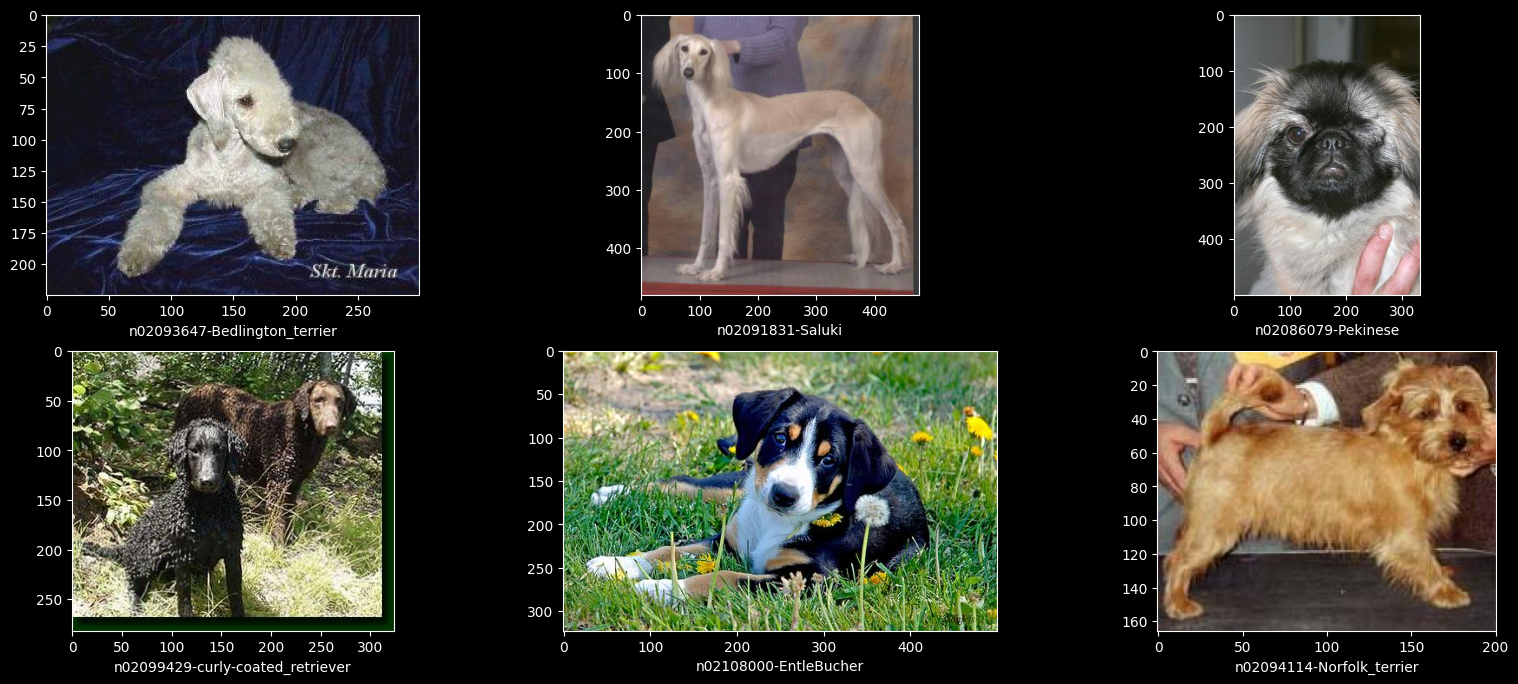

In [4]:
idx = plot_random_six_images(dataset, dataset.classes)

## Loding Model and Prediction

In [5]:
MODEL_NAME = 'resnet18_dogs_5_epochs'

net_model = resnet.resnet18()
net_model.load_state_dict(torch.load(os.path.join('models', f"{MODEL_NAME}.pth"), weights_only=True))

preds, df = test_on_given_idx(dataset, net_model,transform, idx=idx)

df

,Idx,True_Label,Predicted_Label
0,5567,n02093647-Bedlington_terrier,n02093647-Bedlington_terrier
1,4570,n02091831-Saluki,n02091831-Saluki
2,699,n02086079-Pekinese,n02086079-Pekinese
3,9936,n02099429-curly-coated_retriever,n02099429-curly-coated_retriever
4,15558,n02108000-EntleBucher,n02108000-EntleBucher
5,6311,n02094114-Norfolk_terrier,n02094114-Norfolk_terrier


array([ 5567,  4570,   699,  9936, 15558,  6311])

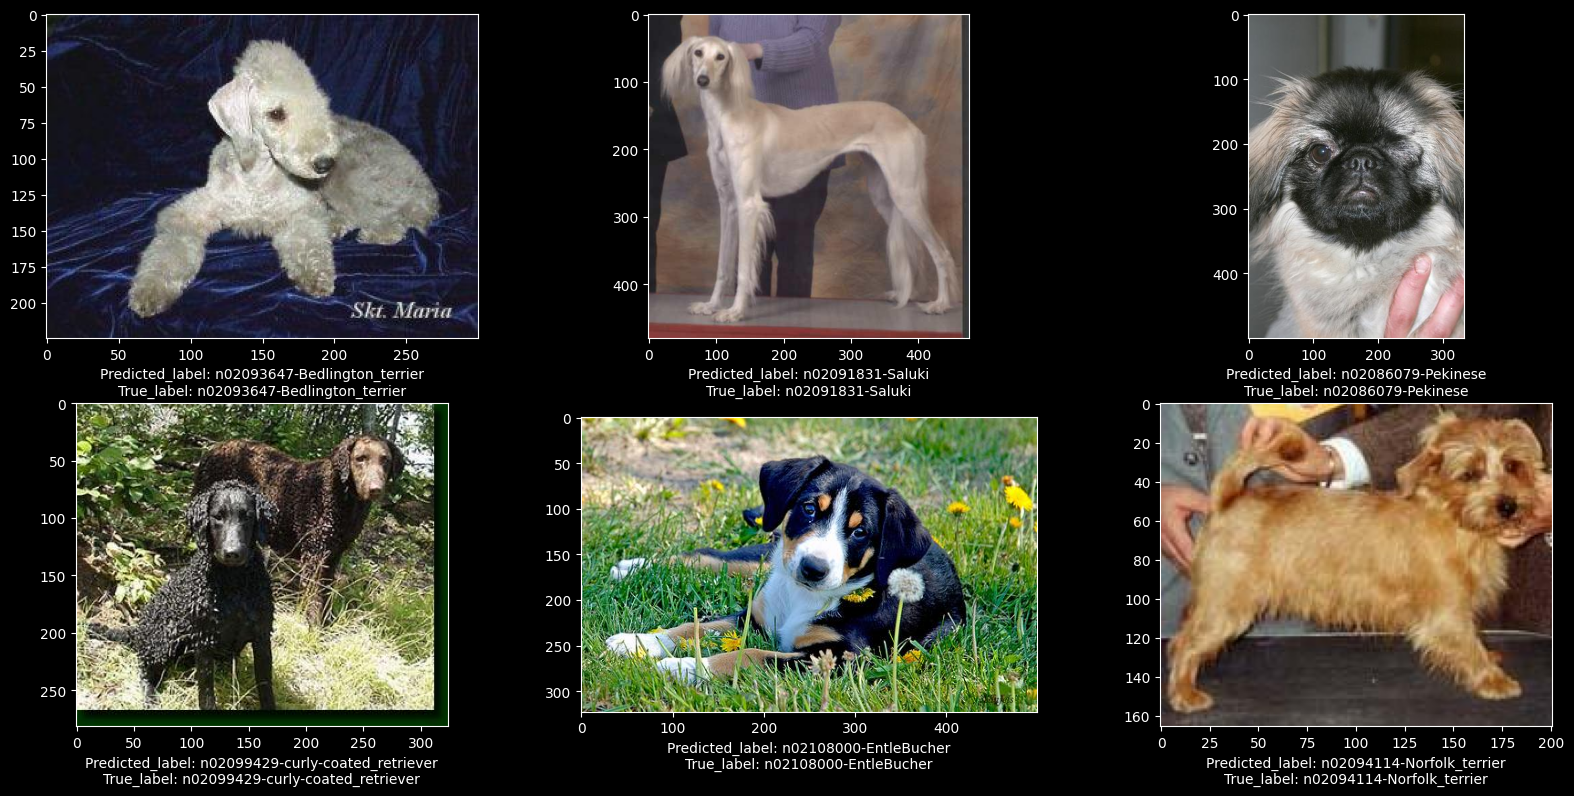

In [7]:
plot_idx_labeled(idx,preds,dataset)

# Guided GradCAM
Guided GradCAM is a combination of GradCAM methods with guided Backpropagation.

## Layer4
The fine tuned one

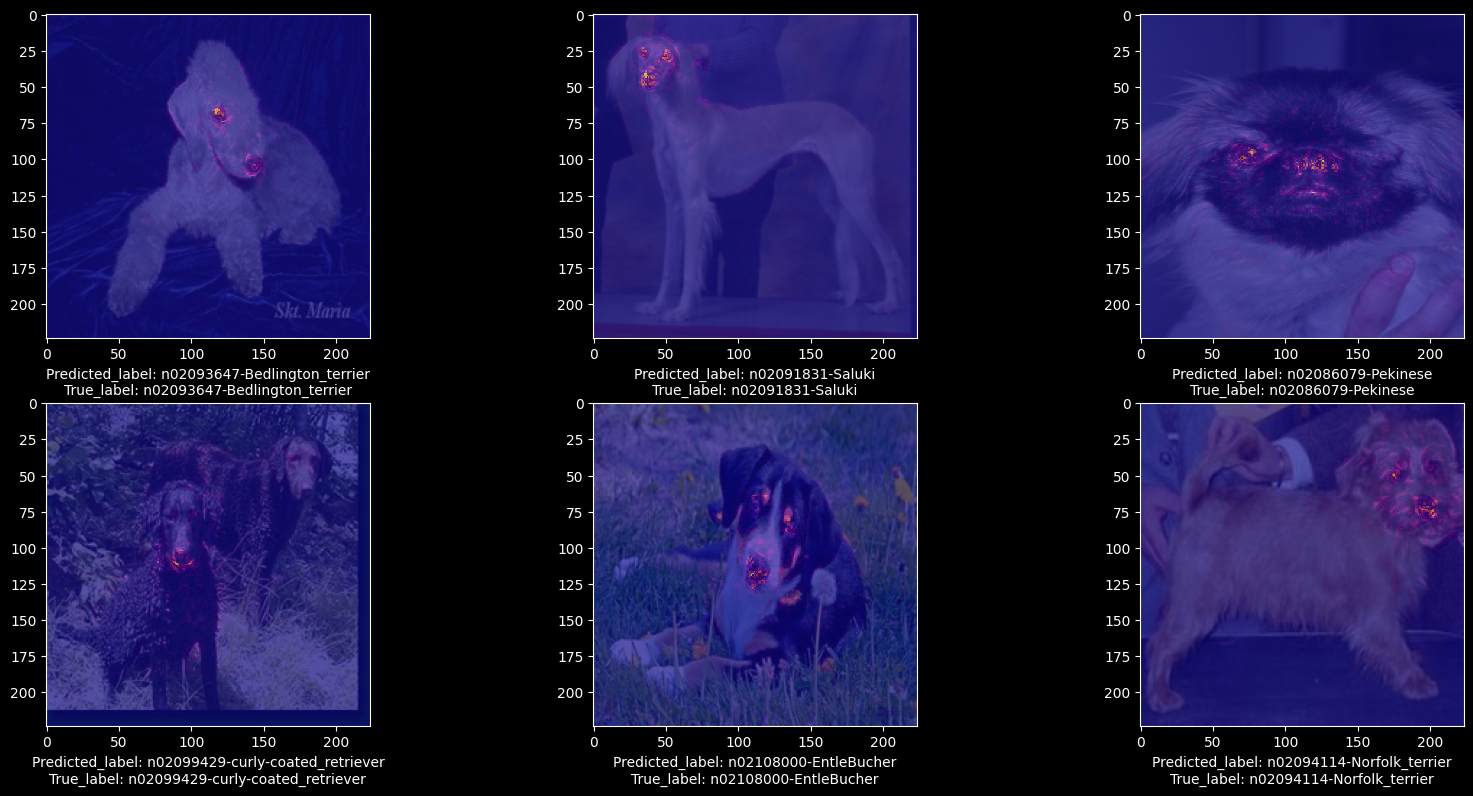

In [8]:
guided_gc = GuidedGradCam(net_model.cpu(), net_model.layer4)
plot_with_function(idx, preds, dataset, guided_gc.attribute, transform=transform)

## Layer 1
As the first feature extraction

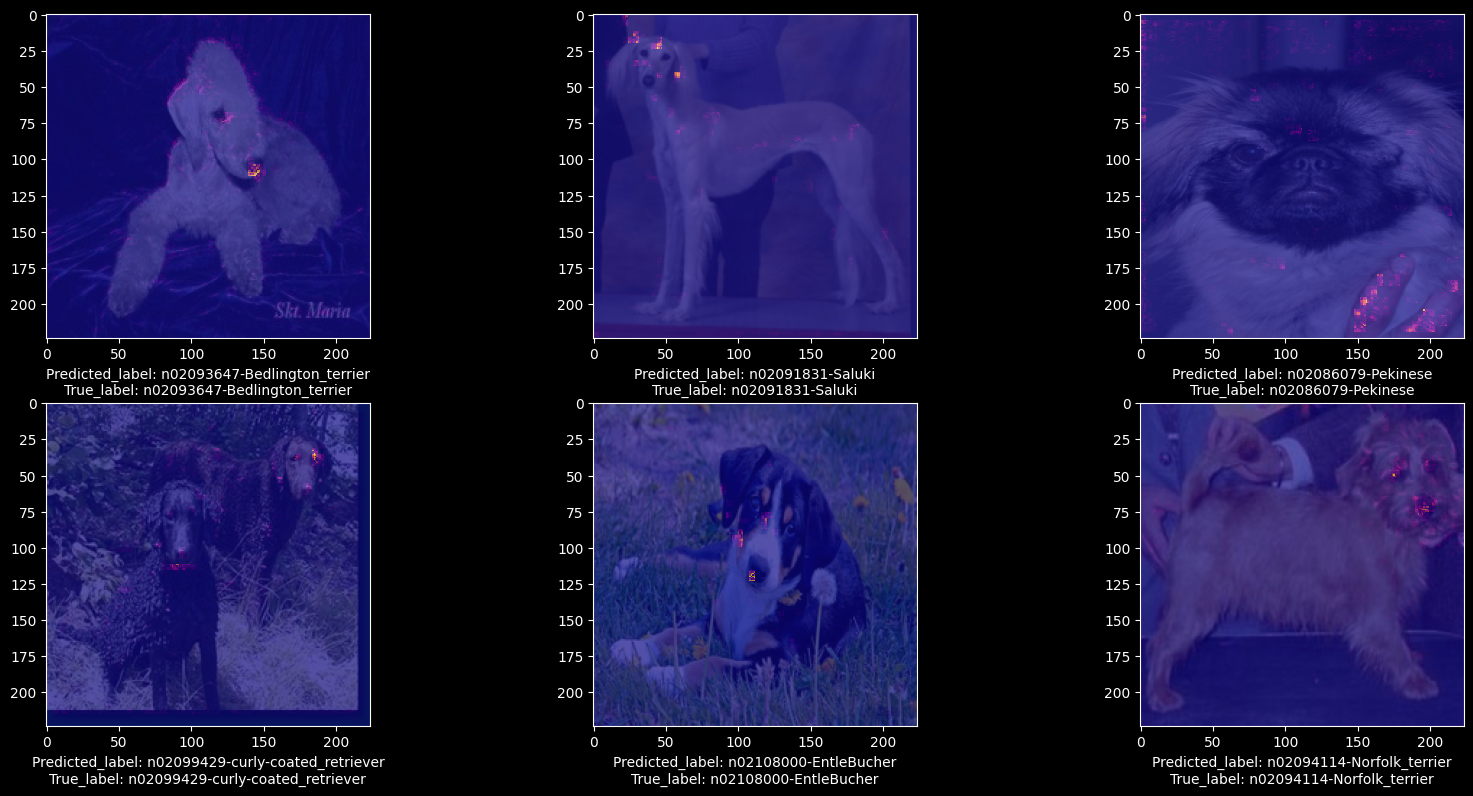

In [9]:
guided_gc1 = GuidedGradCam(net_model.cpu(), net_model.layer1)
plot_with_function(idx, preds, dataset, guided_gc1.attribute, transform=transform)

# Intagrated Gradients


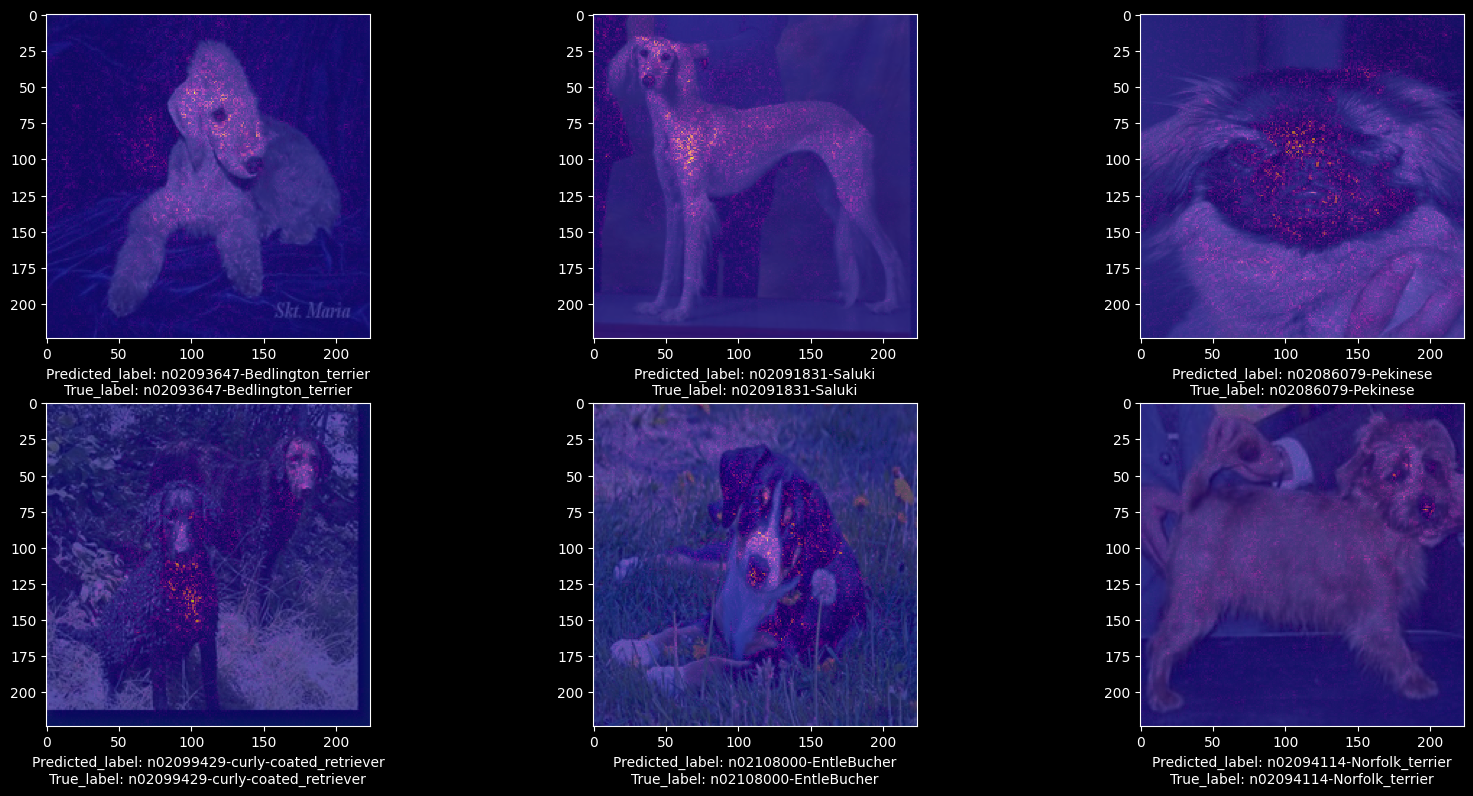

In [10]:
ic = IntegratedGradients(net_model.cpu())
plot_with_function(idx, preds, dataset, ic.attribute, transform=transform)

# Input X Gradient

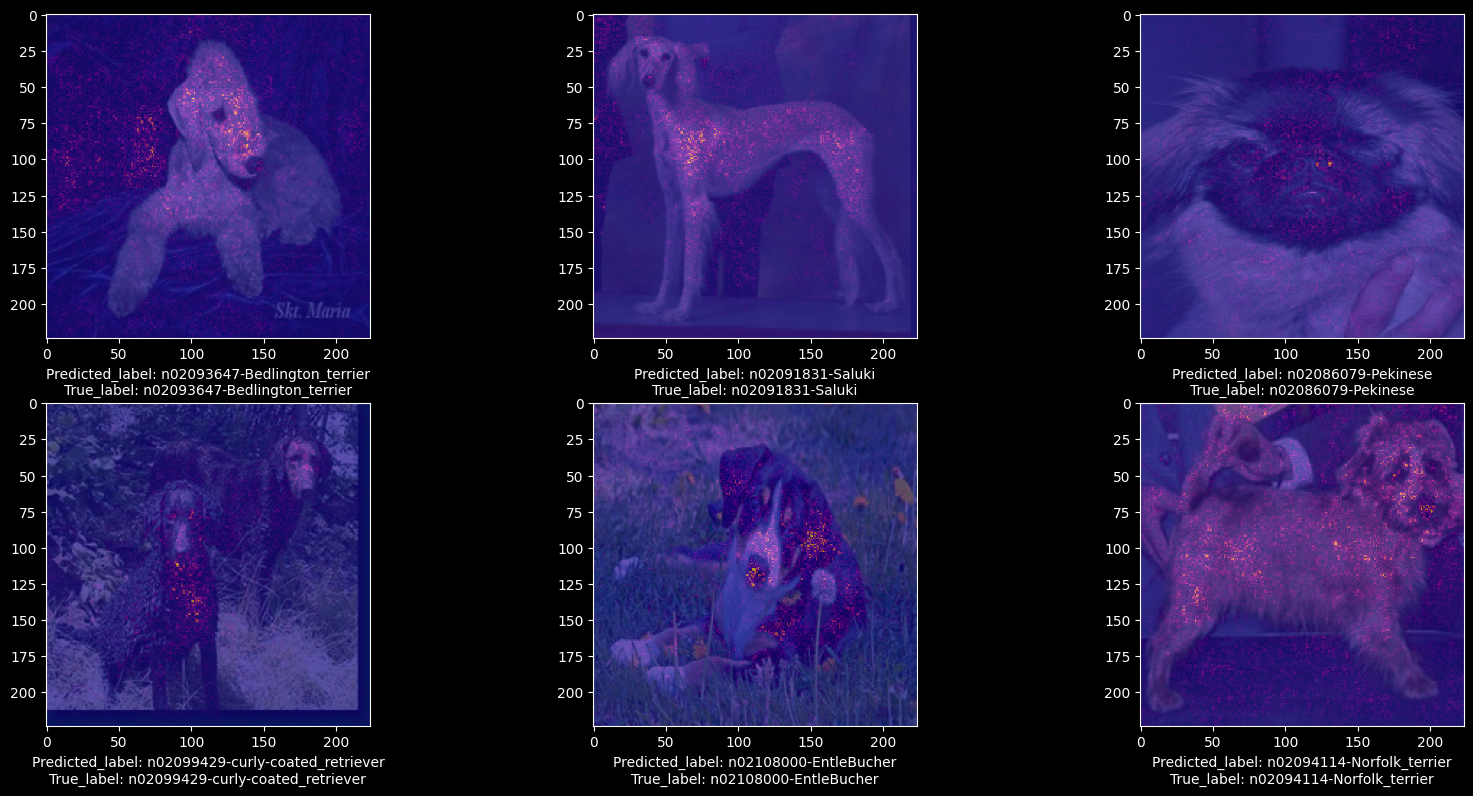

In [11]:
ixg = InputXGradient(net_model)
plot_with_function(idx, preds, dataset, ixg.attribute, transform=transform)